In [1]:
import cv2
import numpy as np
import os
from random import shuffle
from tqdm import tqdm

# TRAIN_DIR = 'https://Kaggle_Data/dogs_vs_cats/train/train'
# TEST_DIR = 'https://www.kaggle.com/competitions/dogs-vs-cats-redux-kernels-edition/data?select=test.zip'

TRAIN_DIR = r"D:\DC\train\train"
TEST_DIR = r"D:\DC\test\test"
IMG_SIZE = 50
LR = 1e-3  # 0.001

MODEL_NAME = 'dogsvscats-{}-{}.model'.format(LR, '6conv-basic-video')
MODEL_NAME

'dogsvscats-0.001-6conv-basic-video.model'

In [2]:
def label_img(img):
    word_label = img.split('.')[-3]
    if word_label == 'cat':
      return [1, 0]
    elif word_label == 'dog':
      return [0, 1]

In [3]:
def create_train_data():
    train_data = []

    for img in tqdm(os.listdir(TRAIN_DIR)):
        label = label_img(img)
        path = os.path.join(TRAIN_DIR, img)

        img = cv2.resize(
            cv2.imread(path, cv2.IMREAD_GRAYSCALE),
            (IMG_SIZE, IMG_SIZE)
        )

        train_data.append([np.array(img), np.array(label)])

    shuffle(train_data)

    np.save('train_data_npy', np.array(train_data, dtype=object))

    return train_data

In [4]:
train_data = create_train_data()

100%|██████████| 25000/25000 [04:21<00:00, 95.72it/s] 


In [5]:
def process_test_data():
    testing_data = []

    for img in tqdm(os.listdir(TEST_DIR)):
        path = os.path.join(TEST_DIR, img)

        img_num = img.split('.')[0]

        img = cv2.resize(
            cv2.imread(path, cv2.IMREAD_GRAYSCALE),
            (IMG_SIZE, IMG_SIZE)
        )

        testing_data.append([
            np.array(img),
            img_num
        ])

    np.save(
        'test_data.npy',
        np.array(testing_data, dtype=object)
    )

    return testing_data

In [6]:
test_data = process_test_data()

100%|██████████| 12500/12500 [00:58<00:00, 212.11it/s]


In [7]:
import os

print("Current folder:", os.getcwd())
print("TEST_DIR:", TEST_DIR)
print("Files in TEST_DIR:", len(os.listdir(TEST_DIR)))

Current folder: C:\Users\Sumit Kumar\OneDrive\Documents\Desktop\M\DL\CNN-DvsC
TEST_DIR: D:\DC\test\test
Files in TEST_DIR: 12500


In [8]:
import tflearn

from tflearn.layers.conv import conv_2d, max_pool_2d
from tflearn.layers.core import input_data, dropout, fully_connected
from tflearn.layers.estimator import regression

import tensorflow as tf

# Reset TensorFlow graph
tf.compat.v1.reset_default_graph()


# =========================
# Input Layer
# =========================
convnet = input_data(
    shape=[None, IMG_SIZE, IMG_SIZE, 1],
    name='input'
)


# =========================
# Convolution Block 1
# =========================
convnet = conv_2d(
    convnet,
    32,
    2,
    activation='relu'
)

convnet = max_pool_2d(
    convnet,
    2
)


# =========================
# Convolution Block 2
# =========================
convnet = conv_2d(
    convnet,
    64,
    2,
    activation='relu'
)

convnet = max_pool_2d(
    convnet,
    2
)


# =========================
# Convolution Block 3
# =========================
convnet = conv_2d(
    convnet,
    32,
    2,
    activation='relu'
)

convnet = max_pool_2d(
    convnet,
    2
)


# =========================
# Convolution Block 4
# =========================
convnet = conv_2d(
    convnet,
    64,
    2,
    activation='relu'
)

convnet = max_pool_2d(
    convnet,
    2
)


# =========================
# Convolution Block 5
# =========================
convnet = conv_2d(
    convnet,
    32,
    2,
    activation='relu'
)

convnet = max_pool_2d(
    convnet,
    2
)


# =========================
# Convolution Block 6
# =========================
convnet = conv_2d(
    convnet,
    64,
    2,
    activation='relu'
)

convnet = max_pool_2d(
    convnet,
    2
)


# =========================
# Fully Connected Layer
# =========================
convnet = fully_connected(
    convnet,
    1024,
    activation='relu'
)


# =========================
# Dropout
# =========================
convnet = dropout(
    convnet,
    0.8
)


# =========================
# Output Layer
# =========================
convnet = fully_connected(
    convnet,
    2,
    activation='softmax'
)


# =========================
# Regression / Training Configuration
# =========================
convnet = regression(
    convnet,
    optimizer='adam',
    learning_rate=LR,
    loss='categorical_crossentropy',
    name='targets'
)


# =========================
# Create DNN Model
# =========================
model = tflearn.DNN(
    convnet,
    tensorboard_dir='log'
)

Instructions for updating:
non-resource variables are not supported in the long term
curses is not supported on this machine (please install/reinstall curses for an optimal experience)
Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor
Instructions for updating:
Use tf.initializers.variance_scaling instead with distribution=uniform to get equivalent behavior.
Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor
Instructions for updating:
Please use `rate` instead of `keep_prob`. Rate should be set to `rate = 1 - keep_prob`.


In [9]:
if os.path.exists('{}.meta'.format(MODEL_NAME)):
    model.load(MODEL_NAME)
    print("Model Loaded!")

INFO:tensorflow:Restoring parameters from C:\Users\Sumit Kumar\OneDrive\Documents\Desktop\M\DL\CNN-DvsC\dogsvscats-0.001-6conv-basic-video.model
Model Loaded!


In [10]:
train = train_data[:24448]
test = train_data[24448:24960]

In [11]:
X = np.array([i[0] for i in train]).reshape(-1, IMG_SIZE, IMG_SIZE, 1)
Y = [i[1] for i in train]

test_X = np.array([i[0] for i in test]).reshape(-1, IMG_SIZE, IMG_SIZE, 1)
test_Y = [i[1] for i in test]

In [12]:
print("X:", X.shape)
print("Y:", len(Y))
print("test_X:", test_X.shape)
print("test_Y:", len(test_Y))

X: (24448, 50, 50, 1)
Y: 24448
test_X: (512, 50, 50, 1)
test_Y: 512


In [13]:
model.fit(
    {'input': X},
    {'targets': Y},
    n_epoch=5,
    validation_set=(
        {'input': test_X},
        {'targets': test_Y}
    ),
    snapshot_step=500,
    show_metric=True,
    run_id=MODEL_NAME
)

Training Step: 17189  | total loss: 0.15348 | time: 47.140s
| Adam | epoch: 005 | loss: 0.15348 - acc: 0.9560 -- iter: 24384/24448
Training Step: 17190  | total loss: 0.14999 | time: 48.298s
| Adam | epoch: 005 | loss: 0.14999 - acc: 0.9557 | val_loss: 0.27479 - val_acc: 0.9082 -- iter: 24448/24448
--


In [14]:
model.save(MODEL_NAME)

INFO:tensorflow:C:\Users\Sumit Kumar\OneDrive\Documents\Desktop\M\DL\CNN-DvsC\dogsvscats-0.001-6conv-basic-video.model is not in all_model_checkpoint_paths. Manually adding it.


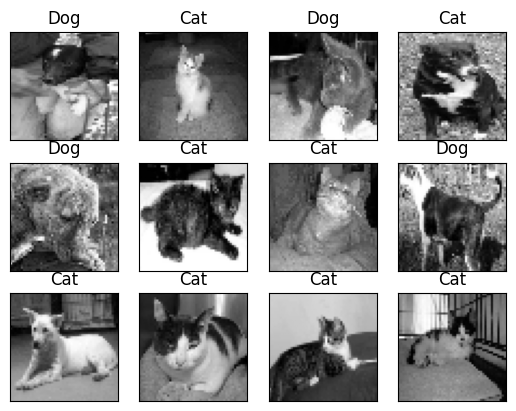

In [15]:
import matplotlib.pyplot as plt

# test_data = process_test_data()
test_data = np.load('test_data.npy', allow_pickle=True)

fig = plt.figure()

for num, data in enumerate (test_data[:12]):
    # cat: [1,0]
    #dog: [0,1]

    img_num = data[1]
    img_data = data[0]

    y = fig.add_subplot(3,4,num+1)
    orig = img_data
    data = img_data.reshape(IMG_SIZE, IMG_SIZE, 1)

    model_out = model.predict([data])[0]

    if np.argmax(model_out) == 1: str_label='Dog'
    else: str_label='Cat'

    y.imshow(orig, cmap='gray')
    plt.title(str_label)
    y.axes.get_xaxis().set_visible(False)
    y.axes.get_yaxis().set_visible(False)

plt.show()

In [18]:
with open('submission-file.csv','w') as f:
    f.write('id, label\n')

In [19]:
with open('submission-file.csv','w') as f:
    for data in tqdm(test_data):
       img_num = data[1]
       img_data = data[0]

       y = fig.add_subplot(3,4,num+1)
       orig = img_data
       data = img_data.reshape(IMG_SIZE, IMG_SIZE, 1)

       model_out = model.predict([data])[0]

       f.write('{},{}\n'.format(img_num, model_out[1]))
    

100%|██████████| 12500/12500 [04:50<00:00, 43.08it/s] 
